In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [3]:
(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


In [8]:
print(X_train.shape)
print(type(X_train))

(60000, 28, 28)
<class 'numpy.ndarray'>


In [18]:
Y_train.shape

(60000,)

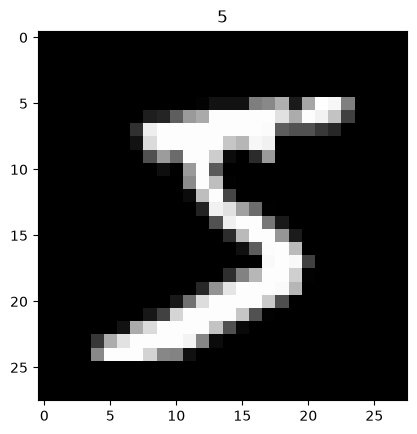

In [9]:
plt.imshow(X_train[0], cmap="gray")
plt.title(Y_train[0])
plt.show()

In [12]:
X_train = X_train / 255
X_test = X_test / 255

In [13]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [14]:
X_train.shape

(60000, 28, 28, 1)

In [27]:
model = keras.Sequential([
    keras.Input((28,28,1)),
    keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu",
    ),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(
        64,
        activation="relu"
    ),
    keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [28]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy,
    metrics=[
        keras.metrics.SparseCategoricalAccuracy
    ]
)

In [29]:
model.output_shape
model.loss

keras.src.losses.losses.SparseCategoricalCrossentropy

In [30]:
model.fit(
    X_train,
    Y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.1435 - sparse_categorical_accuracy: 0.9561
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0464 - sparse_categorical_accuracy: 0.9855
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0323 - sparse_categorical_accuracy: 0.9900
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0246 - sparse_categorical_accuracy: 0.9922
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0186 - sparse_categorical_accuracy: 0.9939


In [32]:
loss, accuracy = model.evaluate(X_test, Y_test)
accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0312 - sparse_categorical_accuracy: 0.9892


0.9891999959945679

In [36]:
prediction = model.predict(X_test[:1])
print(prediction.argmax())
print(Y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
7
7
